In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.formula.api as smf
import statsmodels.api as sm
import joblib
from math import ceil
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

https://www.kaggle.com/datasets/START-UMD/gtd

In [5]:
df = pd.read_csv('../data/globalterrorismdb_0718dist.csv')
df = df.copy()
df.sample(10, random_state=42)
# Random_state -- save time for running the code again

C:\Users\hungh\AppData\Local\Temp\ipykernel_20824\226401783.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/globalterrorismdb_0718dist.csv')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
83552,200706120042,2007,6,12,NaN,0,NaN,153,Pakistan,6,...,NaN,"�Student leader gunned down in Karachi,� Pakis...",�Selection list: Pakistan press Nawa-e Waqt 14...,�Selection list: Pakistan press Ummat 14 Jun 0...,CETIS,-9,-9,0,-9,NaN
30191,198702160006,1987,2,16,NaN,0,NaN,45,Colombia,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
51303,199205060002,1992,5,6,NaN,0,NaN,92,India,6,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
73581,200201030001,2002,1,3,NaN,0,NaN,167,Russia,9,...,NaN,�At least 6 civilians reported killed in Chech...,NaN,NaN,CETIS,0,0,0,0,"200201030001, 200201030002, 200201030003"
17703,198212310013,1982,12,31,NaN,0,NaN,69,France,8,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
174077,201704200007,2017,4,20,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Roadside Bomb Hits AU Military Convo...","""Program Summary: Radio Andalus in Somali 1030...",NaN,START Primary Collection,0,1,1,1,NaN
132395,201405240203,2014,5,24,NaN,1,NaN,195,Sudan,11,...,NaN,"""Peacekeepers in North Darfur's Kabkabiya 'Sho...",NaN,NaN,START Primary Collection,0,0,0,0,"201405240202, 201405240203, 201405240204"
12791,198102010004,1981,2,1,NaN,0,NaN,83,Guatemala,2,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,0,-9,NaN
154258,201510150035,2015,10,15,2015-10-15 00:00:00,0,NaN,92,India,6,...,NaN,"""Maoist arrested in Latehar district, arms sei...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
28720,198607230002,1986,7,23,NaN,0,NaN,45,Colombia,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN


In [6]:
print(df.shape)

(181691, 135)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [ ]:
df = df.rename(columns={'extended': 'more_than_24hrs'})
df = df.drop(columns=['eventid' , 'summary', 'location', 'scite1', 'scite2', 'scite3', 
                      'weapdetail', 'propcomment', 'addnotes', 'related', 'dbsource', 'related',
                      'ransomnote'
                      ])
### I'm not geospartial analysis

In [9]:
df.sample(10)

,iyear,imonth,iday,approxdate,more_than_24hrs,resolution,country,country_txt,region,region_txt,...,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
82988,2007,5,7,NaN,0,NaN,95,Iraq,10,Middle East & North Africa,...,NaN,NaN,NaN,4.0,Hostage(s) killed (not during rescue attempt),0.0,-9,-9,0,-9
13384,1981,4,27,NaN,0,NaN,159,Peru,3,South America,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
130877,2014,4,26,NaN,0,NaN,182,Somalia,11,Sub-Saharan Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,-9,-9,0,-9
75154,2003,2,18,NaN,0,NaN,4,Afghanistan,6,South Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,-9,-9,0,-9
107995,2012,5,18,NaN,0,NaN,160,Philippines,5,Southeast Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
68270,1998,10,17,NaN,0,NaN,235,Yugoslavia,9,Eastern Europe,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1
16565,1982,7,13,NaN,0,NaN,83,Guatemala,2,Central America & Caribbean,...,NaN,NaN,NaN,NaN,NaN,NaN,-9,-9,0,-9
45092,1991,1,10,NaN,0,NaN,78,Greece,8,Western Europe,...,NaN,NaN,NaN,NaN,NaN,NaN,-9,-9,0,-9
38978,1989,7,24,NaN,0,NaN,4,Afghanistan,6,South Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,-9,-9,0,-9
137054,2014,8,26,2014-08-26 00:00:00,0,NaN,95,Iraq,10,Middle East & North Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 123 entries, iyear to INT_ANY
dtypes: float64(55), int64(21), object(47)
memory usage: 170.5+ MB


In [11]:
df.describe()

,iyear,imonth,iday,more_than_24hrs,country,region,latitude,longitude,specificity,vicinity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,181691.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,0.068297,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,0.284553,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,-9.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,0.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,0.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,0.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,1.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)


gsubname3           181671
weapsubtype4        181621
weapsubtype4_txt    181621
weaptype4           181618
weaptype4_txt       181618
                     ...  
guncertain1            380
ishostkid              178
specificity              6
doubtterr                1
multiple                 1
Length: 96, dtype: int64

In [13]:
df.dtypes.value_counts()

float64    55
object     47
int64      21
Name: count, dtype: int64

### EDA -> Data Visualuzation before applying ML models
    Data Cleaning

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(df[num_cols].dtypes.count())

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(df[cat_cols].dtypes.count())


76
47


In [15]:
num_cols

['iyear',
 'imonth',
 'iday',
 'more_than_24hrs',
 'country',
 'region',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype2',
 'attacktype3',
 'targtype1',
 'targsubtype1',
 'natlty1',
 'targtype2',
 'targsubtype2',
 'natlty2',
 'targtype3',
 'targsubtype3',
 'natlty3',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 'claimed',
 'claimmode',
 'claim2',
 'claimmode2',
 'claim3',
 'claimmode3',
 'compclaim',
 'weaptype1',
 'weapsubtype1',
 'weaptype2',
 'weapsubtype2',
 'weaptype3',
 'weapsubtype3',
 'weaptype4',
 'weapsubtype4',
 'nkill',
 'nkillus',
 'nkillter',
 'nwound',
 'nwoundus',
 'nwoundte',
 'property',
 'propextent',
 'propvalue',
 'ishostkid',
 'nhostkid',
 'nhostkidus',
 'nhours',
 'ndays',
 'ransom',
 'ransomamt',
 'ransomamtus',
 'ransompaid',
 'ransompaidus',
 'hostkidoutcome',
 'nreleased',
 'INT_LOG',

In [16]:
cat_cols

['approxdate',
 'resolution',
 'country_txt',
 'region_txt',
 'provstate',
 'city',
 'alternative_txt',
 'attacktype1_txt',
 'attacktype2_txt',
 'attacktype3_txt',
 'targtype1_txt',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1_txt',
 'targtype2_txt',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2_txt',
 'targtype3_txt',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'claimmode_txt',
 'claimmode2_txt',
 'claimmode3_txt',
 'weaptype1_txt',
 'weapsubtype1_txt',
 'weaptype2_txt',
 'weapsubtype2_txt',
 'weaptype3_txt',
 'weapsubtype3_txt',
 'weaptype4_txt',
 'weapsubtype4_txt',
 'propextent_txt',
 'divert',
 'kidhijcountry',
 'hostkidoutcome_txt']

In [17]:
# df.iloc[:, 1:8].sample(10)

#### National Security Strategy (NSS) and the National Defense Strategy (NDS) .
    China
    Russia
    Iran
    North Korea
    Terrorist groups (like ISIS and al-Qaeda)

Zone in US-affected -> industry,Target(s)

#### Important fields
    country_txt - This field identifies the country or location where the incident occurred.
    region_txt -This field identifies the region in which the incident occurred.
    city - Name of the city, village, or town in which the incident occurred

    targtype1_txt - The general type of target/victim
    targsubtype1_txt - The more specific target category
    target1 -The specific person, building, installation that was targeted and/or victimized
    weaptype1_txt 


<Axes: ylabel='region_txt'>

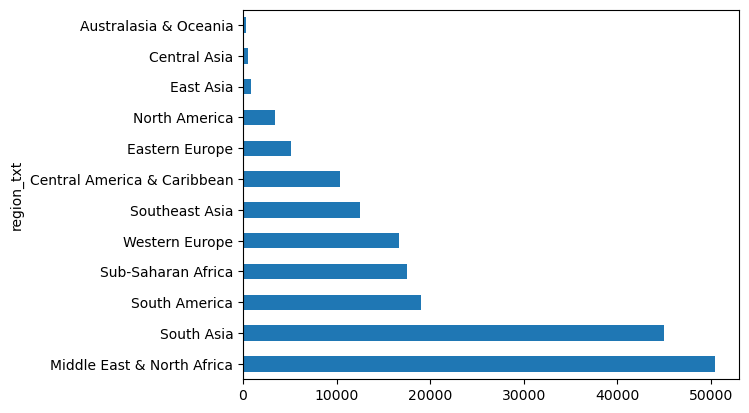

In [18]:
incidents_per_region = df.groupby('region_txt').size().sort_values(ascending=False)
incidents_per_region.plot(kind='barh')